In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('..')

import warnings

# Tắt cảnh báo
warnings.filterwarnings('ignore')
# Đổi style và set kích thước cho biểu đồ
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load the dataset
df = pd.read_csv('data/processed/02_missing_handled.csv')
# Chuyển cột thời gian sang datetime
df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'])
# Sắp xếp dữ liệu theo SID và thời gian
df = df.sort_values(['SID', 'ISO_TIME']).reset_index(drop=True)

# In thông tin cơ bản về dataset
print(f'Dataset: {df.shape[0]:,} dòng | {df["SID"].nunique():,} cơn bão')
print(f'Giai đoạn: {df["YEAR"].min()} – {df["YEAR"].max()}')

Dataset: 40,847 dòng | 719 cơn bão
Giai đoạn: 2000 – 2025


In [2]:
# Thống kê các biến chính
print(df[['WMO_WIND', 'WMO_PRES', 'LAT', 'LON']].describe().round(2))

       WMO_WIND  WMO_PRES       LAT       LON
count  22073.00  32998.00  40847.00  40847.00
mean      54.07    985.66     19.07    121.75
std       22.50     21.78     10.32     20.47
min        3.00    885.00    -28.50     51.00
25%       35.00    977.70     12.80    111.90
50%       50.00    994.00     17.90    124.10
75%       70.00   1000.30     23.30    133.20
max      130.00   1016.00     61.70    194.00


## Phân loại Outlier trong dữ liệu bão

Outlier trong bộ dữ liệu bão chia thành 2 nhóm:

| Loại | Outlier | Xử lý |
|------|---------|-------|
| **Intrinsic** (thật về mặt vật lý) | WMO_WIND cao, WMO_PRES thấp, RI/RW thực sự | Giữ nguyên — phản ánh đúng thực tế khí tượng |
| **Extrinsic** (lỗi dữ liệu) | Spike cô lập, W-P vi phạm nặng, Translation speed > 60 kt | Cap hoặc Drop sau khi kiểm tra từng trường hợp |

**Kiểm tra outlier theo 4 tiêu chuẩn vật lý**:

| # | Loại | Kiểm tra | Ngưỡng | Nguồn |
|---|------|----------|--------|-------|
| 1 | Intrinsic | WMO_WIND cực đoan / WMO_PRES cực thấp | WMO_WIND > 150 kt hoặc WMO_PRES < 900 mb | Kỷ lục lịch sử (Tip 1979, Haiyan 2013) |
| 1 | Intrinsic | Rapid Intensification / Weakening (RI/RW) | \|dWIND\_24h\| ≥ 35 knots; kiểm tra thêm spike cô lập \|dWIND\_3h\| ≥ 30 kt | NOAA/NHC |
| 2 | Extrinsic | Wind–Pressure Consistency | dWIND và dPRES cùng chiều + biên độ lớn (\|dWIND\| > 10 kt và \|dPRES\| > 5 mb) | Knaff & Zehr (2007) |
| 2 | Extrinsic | Translation speed | > 60 knots (~111 km/h) giữa 2 điểm liên tiếp | Chavas & Emanuel (2010) |

**Quy trình chung:** Phân loại Intrinsic/Extrinsic -> Flag những điểm đáng ngờ -> Intrinsic giữ nguyên; Extrinsic thì Cap (spike, W-P vi phạm nặng) hoặc Drop (translation speed bất thường) tùy mức độ.

---
## 1. INTRINSIC OUTLIER

## 1.1. Intrinsic: WMO_WIND cao / WMO_PRES thấp

**Nguyên lý**: Giá trị cực đoan của WMO_WIND và WMO_PRES (WMO_WIND quá cao, WMO_PRES thấp) có thật, nó là sự thật về mặt vật lý. Ví dụ:
- Typhoon Tip (1979): WMO_WIND = 185 knots, WMO_PRES = 870 mb — kỷ lục thế giới
- Typhoon Haiyan (2013): WMO_WIND = 170 knots — được xác nhận bởi nhiều nguồn độc lập

In [3]:
# XÁC ĐỊNH INTRINSIC OUTLIER: WMO_WIND CAO, WMO_PRES THẤP

# Ngưỡng để xác định outlier
WIND_EXTREME  = 150   # knots
PRES_EXTREME  = 900   # mb

# Flag
df['flag_wind_extreme'] = df['WMO_WIND'] > WIND_EXTREME
df['flag_pres_extreme'] = df['WMO_PRES'] < PRES_EXTREME

# Đếm số lượng các Flag True (các dòng cực đoan)
n_wind_extreme = df['flag_wind_extreme'].sum()
n_pres_extreme = df['flag_pres_extreme'].sum()

# In ra các dòng (obs) cực đoan
print(f'WMO_WIND > {WIND_EXTREME} knots: {n_wind_extreme} obs')
if n_wind_extreme > 0:
    print(df[df['flag_wind_extreme']][['SID','ISO_TIME','WMO_WIND','WMO_PRES']].to_string())

print(f'\nWMO_PRES < {PRES_EXTREME} mb: {n_pres_extreme} obs')
if n_pres_extreme > 0:
    print(df[df['flag_pres_extreme']][['SID','ISO_TIME','WMO_WIND','WMO_PRES']].to_string())

total_intrinsic = (df["flag_wind_extreme"] | df["flag_pres_extreme"]).sum()

n_storm_intrinsic = df[df["flag_wind_extreme"] | df["flag_pres_extreme"]]["SID"].nunique()
print(f'\nTổng: {total_intrinsic} obs từ {n_storm_intrinsic} cơn bão')
print('→ Đây là Intrinsic Outlier — có cơ sở vật lý (các siêu bão lịch sử), KHÔNG xử lý.')

WMO_WIND > 150 knots: 0 obs

WMO_PRES < 900 mb: 17 obs
                 SID            ISO_TIME  WMO_WIND  WMO_PRES
16533  2010285N13145 2010-10-17 12:00:00     120.0     895.0
16534  2010285N13145 2010-10-17 15:00:00     123.3     888.8
16535  2010285N13145 2010-10-17 18:00:00     125.0     885.0
16536  2010285N13145 2010-10-17 21:00:00     125.0     885.0
16537  2010285N13145 2010-10-18 00:00:00     125.0     885.0
16538  2010285N13145 2010-10-18 03:00:00     117.1     894.1
21729  2013306N07162 2013-11-07 12:00:00     125.0     895.0
21730  2013306N07162 2013-11-07 15:00:00     125.0     895.0
21731  2013306N07162 2013-11-07 18:00:00     125.0     895.0
25482  2016253N13144 2016-09-13 09:00:00     117.5     895.0
25483  2016253N13144 2016-09-13 12:00:00     120.0     890.0
25484  2016253N13144 2016-09-13 15:00:00     118.3     893.8
33779  2021102N06144 2021-04-17 15:00:00     116.2     898.3
33780  2021102N06144 2021-04-17 18:00:00     120.0     895.0
33781  2021102N06144 2021-04-1

> **Kết luận → Giữ nguyên**: WMO_WIND (cường độ bão) cao, WMO_PRES (áp suất bão) thấp là hiện tượng tự nhiên, có ngoài thực tế và có cơ sở vật lý, nên không xử lý

## 1.2. Intrinsic: Rapid Intensification / Weakening (RI/RW) - Bão mạnh lên rất nhanh/Bão yếu đi rất nhanh

**Định nghĩa theo chuẩn NOAA/NHC**: Một cơn gió được coi là một RI nếu tốc độ gió cực đại tăng ít nhất 35 knots trong vòng 24 giờ

Dataset bão ghi nhận dữ liệu mỗi 3 giờ → 24h tương ứng 8 bước thời gian.

Do đó, RI/RW được xác định bằng cách so sánh: ΔWIND_24h = WIND(t) − WIND(t−24h)

Nếu:
- ΔWIND_24h ≥ +35 knots → Rapid Intensification (RI)
- ΔWIND_24h ≤ −35 knots → Rapid Weakening (RW)

RI/RW hiện tượng có thật (Ví dụ cơn bão Haiyan tăng 85 knots trong 24h), nhưng:
- Nếu ΔWIND cực lớn tại 1 điểm duy nhất rồi lại quay về bình thường ngay sau đó → đây là spike cô lập, là 1 Extrinsic
- Nếu ΔWIND lớn **liên tục nhiều điểm** → RI/RW thực sự, giữ nguyên

In [4]:
# PHÁT HIỆN RI/RW/SPIKE CÔ LẬP (nhằm phân biệt các hiện tượng tự nhiên có thật và lỗi dữ liệu)

# Tính mức thay đổi cường độ bão (cách nhau 3h)
df['dWIND_3h'] = df.groupby('SID')['WMO_WIND'].diff()   # knots / 3h
# Tính mức thay đổi áp suất bão (cách nhau 3h)
df['dPRES_3h'] = df.groupby('SID')['WMO_PRES'].diff()   # mb / 3h

# Tính thay đổi trong 24h (cách nhau 8 bước 3h = 24h)
df['dWIND_24h'] = df.groupby('SID')['WMO_WIND'].diff(8)

# Kiểm tra có đúng đủ 24h không, phòng trường hợp có gap dữ liệu
df['dt_8step'] = df.groupby('SID')['ISO_TIME'].diff(8).dt.total_seconds() / 3600

# Ngưỡng RI/RW theo NOAA/NHC
RI_THRESHOLD = 35   # knots / 24h
SPIKE_3H     = 30   # knots / 3h

# Flag RI/RW (hiện tượng thực, giữ nguyên)
df['flag_RI'] = (df['dWIND_24h'] >=  RI_THRESHOLD) & (df['dt_8step'] == 24)
df['flag_RW'] = (df['dWIND_24h'] <= -RI_THRESHOLD) & (df['dt_8step'] == 24)

# Flag các thay đổi cực lớn trong 3h (spike cực đoan - nhưng chưa biết là hiện tượng thật hay lỗi dữ liệu)
df['flag_spike_wind'] = df['dWIND_3h'].abs() >= SPIKE_3H

# Tổng quan
# Thống kê số lượng dòng RI/RW/spike
n_ri = df['flag_RI'].sum()
n_rw = df['flag_RW'].sum()
n_spike = df['flag_spike_wind'].sum()
# Thống kê số lượng cơn bão có ít nhất 1 điểm RI/RW/spike
n_storm_ri = df[df['flag_RI']]['SID'].nunique()
n_storm_rw = df[df['flag_RW']]['SID'].nunique()
n_storm_spike = df[df['flag_spike_wind']]['SID'].nunique()

print('KIỂM TRA: RI / RW / SPIKE')
print(f'Rapid Intensification (ΔWIND_24h ≥ +{RI_THRESHOLD}kt) : {n_ri:5,} obs | {n_storm_ri} storms')
print(f'Rapid Weakening       (ΔWIND_24h ≤ -{RI_THRESHOLD}kt) : {n_rw:5,} obs | {n_storm_rw} storms')
print(f'Spike cực đoan        (|ΔWIND_3h| ≥ {SPIKE_3H}kt) : {n_spike:5,} obs | {n_storm_spike} storms')

# Phân biệt RI/RW và Spike cô lập
# Phân biệt Spike cô lập (nếu có thay đổi cực lớn nhưng điểm tiếp theo đảo chiều ngay)
df['dWIND_3h_next'] = df.groupby('SID')['dWIND_3h'].shift(-1)
df['is_isolated_spike'] = (
    (df['dWIND_3h'].abs() >= SPIKE_3H) &
    (df['dWIND_3h'] * df['dWIND_3h_next'] < 0)    # đảo chiều ngay
)

n_isolated = df['is_isolated_spike'].sum()
print(f'\nSpike cô lập: {n_isolated:,} obs')

if n_isolated > 0:
    print('→ Các điểm spike cô lập này có khả năng lỗi dữ liệu.')

    print(
        df[df['is_isolated_spike']]
        [['SID', 'ISO_TIME', 'WMO_WIND', 'dWIND_3h', 'dWIND_3h_next']]
        .to_string()
    )
else:
    print('→ Không phát hiện spike cô lập theo tiêu chuẩn hiện tại.')

KIỂM TRA: RI / RW / SPIKE
Rapid Intensification (ΔWIND_24h ≥ +35kt) :   348 obs | 82 storms
Rapid Weakening       (ΔWIND_24h ≤ -35kt) :   367 obs | 111 storms
Spike cực đoan        (|ΔWIND_3h| ≥ 30kt) :     1 obs | 1 storms

Spike cô lập: 0 obs
→ Không phát hiện spike cô lập theo tiêu chuẩn hiện tại.


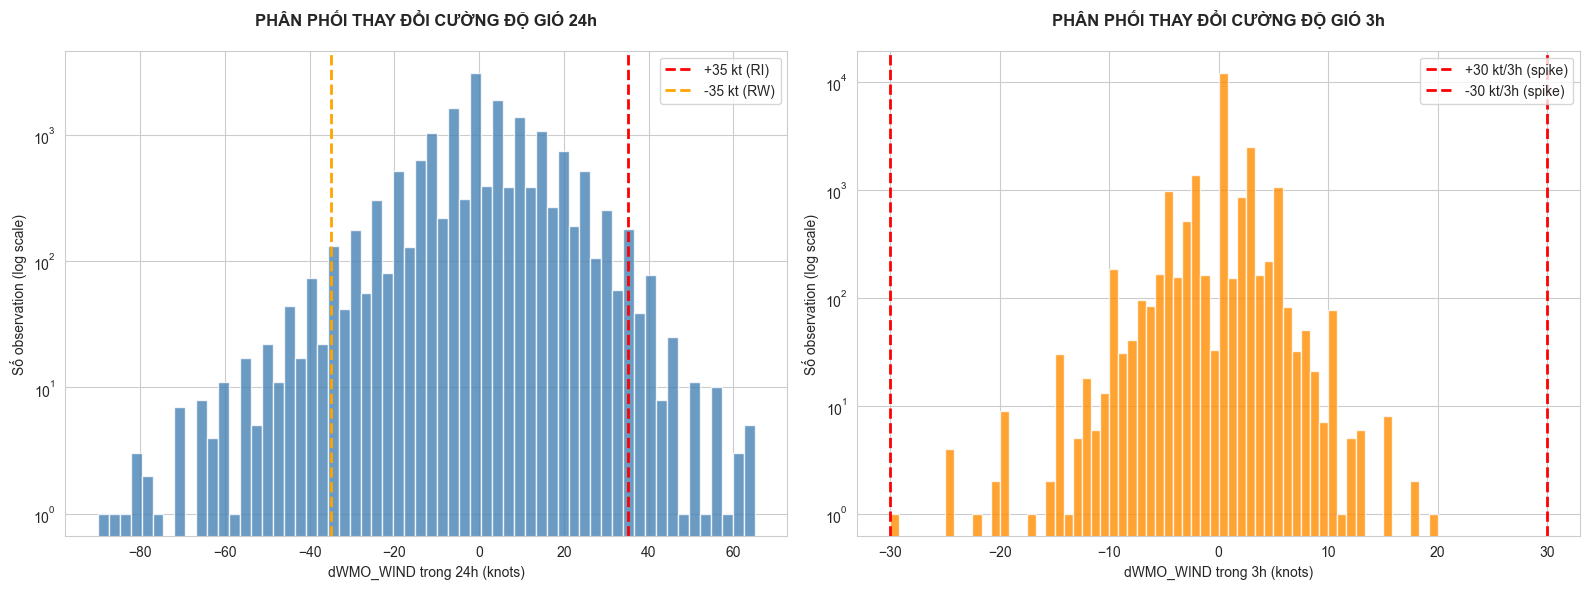


Nhận xét:
- ΔWIND_24h: mean=2.02, std=15.40, max=65.0, min=-90.0
- Tỷ lệ obs RI: 2.09% | RW: 2.20%


In [5]:
# VẼ BIỂU ĐỒ XEM BÃO THAY ĐỔI CƯỜNG ĐỘ MẠNH TỚI MỨC NÀO

# Lấy dữ liệu dWIND_24h hợp lệ (chỉ lấy các bước đúng 24h)
dwind_valid = df[df['dt_8step'] == 24]['dWIND_24h'].dropna()

# Tạo khung vẽ 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vẽ biểu đồ phân phối dWIND_24h
axes[0].hist(dwind_valid, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
# Vẽ các ngưỡng RI/RW
axes[0].axvline( RI_THRESHOLD, color='red',   linestyle='--', lw=2, label=f'+{RI_THRESHOLD} kt (RI)')
axes[0].axvline(-RI_THRESHOLD, color='orange',linestyle='--', lw=2, label=f'-{RI_THRESHOLD} kt (RW)')
# Labels và title
axes[0].set_xlabel('dWMO_WIND trong 24h (knots)')
axes[0].set_ylabel('Số observation')
axes[0].set_title('PHÂN PHỐI THAY ĐỔI CƯỜNG ĐỘ GIÓ 24h\n', fontweight='bold')
# Legend
axes[0].legend()

# Lấy dữ liệu dWIND_3h
dwind3_valid = df['dWIND_3h'].dropna()
# Vẽ biểu đồ phân phối dWIND_3h
axes[1].hist(dwind3_valid, bins=60, color='darkorange', edgecolor='white', alpha=0.8)
# Vẽ các ngưỡng spike (các điểm có thay đổi bất thường)
axes[1].axvline( SPIKE_3H, color='red', linestyle='--', lw=2, label=f'+{SPIKE_3H} kt/3h (spike)')
axes[1].axvline(-SPIKE_3H, color='red', linestyle='--', lw=2, label=f'-{SPIKE_3H} kt/3h (spike)')
# Labels và title
axes[1].set_xlabel('dWMO_WIND trong 3h (knots)')
axes[1].set_ylabel('Số observation')
axes[1].set_title('PHÂN PHỐI THAY ĐỔI CƯỜNG ĐỘ GIÓ 3h\n', fontweight='bold')
# Legend
axes[1].legend()

axes[0].set_yscale('log')
axes[1].set_yscale('log')

axes[0].set_ylabel('Số observation (log scale)')
axes[1].set_ylabel('Số observation (log scale)')

plt.tight_layout()
plt.show()

print('\nNhận xét:')
print(f'- ΔWIND_24h: mean={dwind_valid.mean():.2f}, std={dwind_valid.std():.2f}, max={dwind_valid.max():.1f}, min={dwind_valid.min():.1f}')
# Tỉ lệ RI/RW
print(f'- Tỷ lệ obs RI: {n_ri/len(dwind_valid)*100:.2f}% | RW: {n_rw/len(dwind_valid)*100:.2f}%')

**NHẬN XÉT BIỂU ĐỒ**

1. Biểu đồ PHÂN PHỐI THAY ĐỔI CƯỜNG ĐỘ GIÓ 24H
- Ta thấy phần lớn các dòng dữ liệu (observation) có mức thay đổi cường độ trong 24h gần 0 knots, phân phối tập trung trong khoảng -20 đến 20 knots
- Chỉ một phần nhỏ vượt qua ngưỡng RI/RW
- Nên tỉ lệ obs RI và RW tương đối thấp, chỉ hơn 2%,phù hợp với thực tế vì hiện tượng này tuy có nhưng không xuất hiện nhiều ngoài tự nhiên
- Ngoài ra, ta thấy biểu đồ lệch trái nhẹ, tức là thể hiện bão suy yếu nhanh hơn tăng cường

2. Biểu đồ PHÂN PHỐI THAY ĐỔI CƯỜNG ĐỘ GIÓ 3H
- Ta thấy đa số thay đổi cường độ ngắn hạn khá nhỏ, thường phân phối tập trung trong khoảng -5 đến +5 knots, hợp lý vì bão thường không thay đổi quá nhanh trong vòng 3h
- Về spike cực đoan, chỉ có vài obs nào vượt ngưỡng -30 đến +30 knots, nhưng không cái nào được xác định là spike cô lập, tức là không có spike cô lập trong dataset

> **Kết luận → Giữ nguyên**: RI/RW là hiện tượng vật lý có thật, không xử lý. Ngoài ra, trong dataset không có spike cô lập.

---
## 2. EXTRINSIC OUTLIER

##  2.1. Extrinsic: SPIKE CÔ LẬP
**Nguyên lý:** Nếu WMO_WIND tăng lên bất thường tại 1 thời điểm đó rồi lại quay trở về bình thường thì là thiếu tính liên tục vật lý, có thể là lỗi dữ liệu

**Solution:** Do tọa độ và thời gian vẫn hợp lệ, chỉ có WMO_WIND là bất thường, nên phương pháp xử lý sẽ là CAP về hai điểm liền kề, tức là thay thế giá trị bất thường đó thành trung bình của hai điểm liền kề

In [6]:
n_spike_before = int(df['is_isolated_spike'].fillna(False).sum())

if n_spike_before > 0:
    wind_prev = df.groupby('SID')['WMO_WIND'].shift(1)
    wind_next = df.groupby('SID')['WMO_WIND'].shift(-1)
    cap_value = ((wind_prev + wind_next) / 2).round(1)
    mask_spike = df['is_isolated_spike'].fillna(False)
    # Ghi lại giá trị gốc trước khi cap
    df.loc[mask_spike, 'WMO_WIND_origin'] = df.loc[mask_spike, 'WMO_WIND']
    df.loc[mask_spike, 'WMO_WIND'] = cap_value[mask_spike]
    print(f'Spike cô lập: {n_spike_before} điểm -> đã thay thế điểm bất thường thành trung bình 2 điểm kề')
    print(df.loc[mask_spike, ['SID','ISO_TIME','WMO_WIND_origin','WMO_WIND']].to_string())
else:
    print('Không có spike cô lập -> không cần xử lý')

Không có spike cô lập -> không cần xử lý


## 2.2. Extrinsic/Intrisics: Wind–Pressure Consistency

**Nguyên lý vật lý**: Gió mạnh hơn, Áp suất trung tâm thấp hơn (nghịch chiều). Hay có thể giải thích là WIND và PRESSURE thường biến đổi ngược chiều nhau, và nếu gió và áp suất lại tăng/giảm cùng nhau thì đáng nghi.

- Nếu dWIND và dPRES nhỏ, biên độ nhỏ thì tính là vi phạm nhẹ, là hiện tượng tự nhiên khi bão hình thành hoặc tan rã (Intrinsic) -> giữ nguyên

- Nếu dWIND và dPRES lớn, biên độ lớn thì tính là vi phạm nặng, lúc này là lỗi dữ liệu (Extrinsic) -> cap

**Flag bất thường**: Khi dWIND và dPRES **cùng chiều** (cả hai cùng tăng hoặc cùng giảm) -> vi phạm vật lý.

**Phương pháp nhận biết:** Tính tích của dWIND_3h và dPRES_3h, nếu tích > 0 chứng tỏ hai cái này cùng dấu, vi phạm. Chỉ khi tích < 0 mới là hợp lệ

Tham chiếu: Knaff & Zehr (2007) — *Reexamination of Tropical Cyclone Wind–Pressure Relationships*, WAF.

In [7]:
# KIỂM TRA WIND VÀ PRESSURE có hợp lệ hay không

# Lấy dòng có đủ dữ liệu dWIND_3h và dPRES_3h
mask_wp = df['dWIND_3h'].notna() & df['dPRES_3h'].notna()
df_wp = df[mask_wp].copy()

# Đặt ngưỡng để kiểm tra các noise quá nhỏ, không có ý nghĩa vật lý
WIND_NOISE = 2   # knots
PRES_NOISE = 1   # mb

# Kiểm tra tính nhất quán giữa dWIND_3h và dPRES_3h, nếu tích hai này cùng dấu là vi phạm
df_wp['wp_inconsistent'] = ((df_wp['dWIND_3h'].abs() > WIND_NOISE) & (df_wp['dPRES_3h'].abs() > PRES_NOISE) &
                            (df_wp['dWIND_3h'] * df_wp['dPRES_3h'] > 0))

# Thống kê số vi phạm
n_incon = df_wp['wp_inconsistent'].sum()
# Đếm số cơn bão có ít nhất 1 vi phạm
n_storm_incon = df_wp[df_wp['wp_inconsistent']]['SID'].nunique()
# Tính tỷ lệ vi phạm
pct_incon = n_incon / len(df_wp) * 100

print('KIỂM TRA TÍNH NHẤT QUÁN WIND-PRESSURE')
print(f'Tổng số dòng kiểm tra : {len(df_wp):,}')
print(f'Tổng số vi phạm: {n_incon:,} obs ({pct_incon:.2f}%) | {n_storm_incon} storms')

# Lọc các vi phạm nặng: |dWIND_3h| > 10 knots và |dPRES_3h| > 5 mb và chúng cùng chiều để phân biệt chúng với các vi phạm nhẹ là hiện tượng tự nhiên
HEAVY_VIOLATION = 10
df_wp['wp_heavy_violation'] = ( df_wp['wp_inconsistent']
                               & (df_wp['dWIND_3h'].abs() > HEAVY_VIOLATION)
                               & (df_wp['dPRES_3h'].abs() > 5))
n_heavy = df_wp['wp_heavy_violation'].sum()
print(f'Số dòng vi phạm nặng: {n_heavy:,} obs')

if n_heavy > 0:
    print('\nChi tiết vi phạm nặng:')
    print(df_wp[df_wp['wp_heavy_violation']][
        ['SID','ISO_TIME','WMO_WIND','WMO_PRES','dWIND_3h','dPRES_3h']
    ].to_string())
else:
    print('Không có vi phạm nặng.')

# Merge flag trở lại df gốc
df = df.merge(
    df_wp[['SID', 'ISO_TIME', 'wp_inconsistent', 'wp_heavy_violation']],
    on=['SID', 'ISO_TIME'], how='left'
)
df[['wp_inconsistent', 'wp_heavy_violation']] = df[['wp_inconsistent', 'wp_heavy_violation']].fillna(False)

KIỂM TRA TÍNH NHẤT QUÁN WIND-PRESSURE
Tổng số dòng kiểm tra : 21,461
Tổng số vi phạm: 4 obs (0.02%) | 4 storms
Số dòng vi phạm nặng: 0 obs
Không có vi phạm nặng.


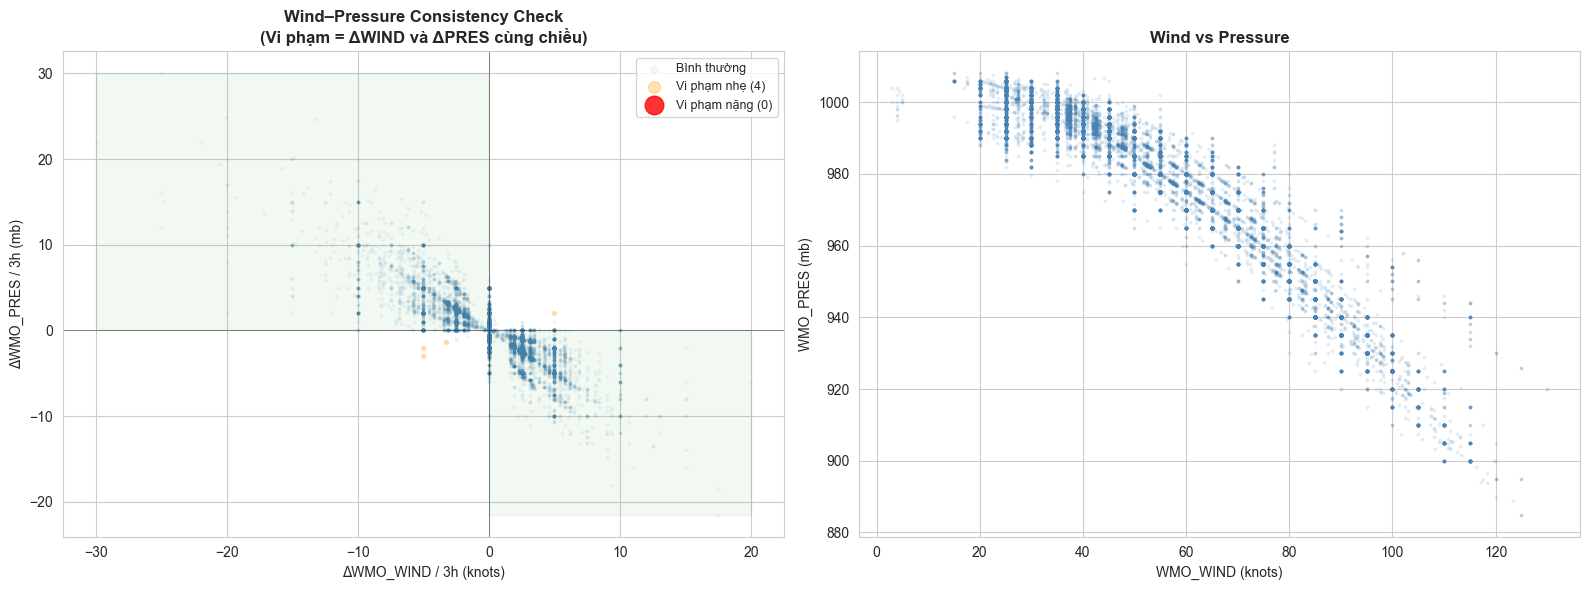


Nhận xét:
- Tỷ lệ vi phạm 0.02% ở mức thấp, chưa đủ bằng chứng kết luận là lỗi, có thể là hiện tượng tự nhiên → giữ nguyên.


In [8]:
# Lấy dữ liệu có đủ WMO_WIND và WMO_PRES
df_plot = df_wp.dropna(subset=['WMO_WIND', 'WMO_PRES'])

# Tạo khung vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chia 3 nhóm dữ liệu để vẽ màu khác nhau
normal = df_wp[~df_wp['wp_inconsistent']]       # Nhóm bình thường, không vi phạm
incon = df_wp[df_wp['wp_inconsistent']]        # Nhóm tổng vi phạm (nhẹ + nặng)
heavy_vio = df_wp[df_wp['wp_heavy_violation']]     # Nhóm vi phạm nặng

# Tính số vi phạm nhẹ
n_incon_light = n_incon - n_heavy

# Vẽ các điểm trong các nhóm
axes[0].scatter(normal['dWIND_3h'], normal['dPRES_3h'],
                alpha=0.05, s=3, color='steelblue', label=f'Bình thường')
axes[0].scatter(incon['dWIND_3h'], incon['dPRES_3h'],
                alpha=0.3, s=8, color='orange', label=f'Vi phạm nhẹ ({n_incon_light:,})')
axes[0].scatter(heavy_vio['dWIND_3h'], heavy_vio['dPRES_3h'],
                alpha=0.8, s=20, color='red', label=f'Vi phạm nặng ({n_heavy})')

# Vẽ các trục ngang và trục dọc
axes[0].axhline(0, color='black', lw=0.5, alpha=0.5)
axes[0].axvline(0, color='black', lw=0.5, alpha=0.5)

# Tô màu vùng bình thường là Q2 (dWIND-, dPRES+) và Q4 (dWIND+, dPRES-)
xmin = df_wp['dWIND_3h'].min()
xmax = df_wp['dWIND_3h'].max()
ymin = df_wp['dPRES_3h'].min()
ymax = df_wp['dPRES_3h'].max()

axes[0].fill_between([xmin, 0], 0, ymax, alpha=0.05, color='green')  # Q2
axes[0].fill_between([0, xmax], ymin, 0, alpha=0.05, color='green')  # Q4

axes[0].set_xlabel('ΔWMO_WIND / 3h (knots)')
axes[0].set_ylabel('ΔWMO_PRES / 3h (mb)')
axes[0].set_title('Wind–Pressure Consistency Check\n(Vi phạm = ΔWIND và ΔPRES cùng chiều)', fontweight='bold')
axes[0].legend(markerscale=3, fontsize=9)

# Vẽ biểu đồ mối quan hệ giữa WIND VÀ PRES
axes[1].scatter(df_plot['WMO_WIND'], df_plot['WMO_PRES'],
                alpha=0.1, s=3, color='steelblue')
# Nếu tồn tại điểm vi phạm nặng thì tô đỏ lên biểu đồ
if n_heavy > 0:
    hv = df_plot[df_plot['wp_heavy_violation']]
    axes[1].scatter(hv['WMO_WIND'], hv['WMO_PRES'],
                    color='red', s=30, zorder=5, label='Vi phạm nặng')
    axes[1].legend()

axes[1].set_xlabel('WMO_WIND (knots)')
axes[1].set_ylabel('WMO_PRES (mb)')
axes[1].set_title('Wind vs Pressure', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nNhận xét:')
if pct_incon < 5:
    print(f'- Tỷ lệ vi phạm {pct_incon:.2f}% ở mức thấp, chưa đủ bằng chứng kết luận là lỗi, có thể là hiện tượng tự nhiên → giữ nguyên.')
elif pct_incon < 15:
    print(f'- Tỷ lệ vi phạm {pct_incon:.2f}% ở mức trung bình, cần phân tích thêm theo BASIN.')
else:
    print(f'- Tỷ lệ vi phạm {pct_incon:.2f}% cao. Kiểm tra kỹ các storm flagged.')

**NHẬN XÉT BIỂU ĐỒ**

1. Phần lớn dữ liệu nằm trong vùng hợp lý vật lý (dWIND và dPRES trái dấu), cho thấy mối quan hệ wind–pressure của bộ dữ liệu nhìn chung nhất quán: tốc độ gió càng mạnh thì áp suất càng thấp, phù hợp với đặc điểm vật lý của bão

2. Tỷ lệ vi phạm rất thấp (~0.02%), chỉ xuất hiện vài điểm lệch nhỏ và không có vi phạm nặng.

3. Các điểm vi phạm có thể do nằm trong giai đoạn chuyển tiếp khi bão hình thành/tan rã, không tính là lỗi dữ liệu nghiêm trọng nên giữ lại

**SOLUTION XỬ LÝ VI PHẠM WIND–PRESSURE**

- Vi phạm nhẹ: Là hiện tượng tự nhiên khi bão hình thành hoặc tan rã -> giữ nguyên
- Vi phạm nặng: Ước tính lại WMO_WIND từ WMO_PRES theo công thức của Atkinson & Holliday (1977):
  
  V_max = 3.04 × (1010 - P_min)^0.644

  Tham chiếu: Atkinson & Holliday (1977), *Tropical Cyclone Minimum Sea Level Pressure/Maximum Sustained Wind Relationship for the Western North Pacific*, Monthly Weather Review, 105, 421–427.

In [9]:
n_heavy_before = int(df['wp_heavy_violation'].fillna(False).sum())

if n_heavy_before > 0:
    mask_heavy = df['wp_heavy_violation'].fillna(False)

    # Ghi lại giá trị gốc trước khi sửa
    df.loc[mask_heavy, 'WMO_WIND_origin'] = df.loc[mask_heavy, 'WMO_WIND']

    # Ước tính lại WMO_WIND từ WMO_PRES theo Atkinson & Holliday (1977)
    df.loc[mask_heavy, 'WMO_WIND'] = (
        3.04 * (1010 - df.loc[mask_heavy, 'WMO_PRES']) ** 0.644
    ).round(1)

    print(f'W-P vi phạm nặng: {n_heavy_before} điểm ước tính lại WMO_WIND từ WMO_PRES')
    print('(Công thức: Atkinson & Holliday 1977, V_max = 3.04 × (1010 - P)^0.644)')
    print(df.loc[mask_heavy, ['SID','ISO_TIME','WMO_WIND_origin','WMO_WIND','WMO_PRES']].to_string())
else:
    print('Không có vi phạm nặng → không cần xử lý')

Không có vi phạm nặng → không cần xử lý


## 2.3. Extrinsic: Translation Speed

**Translation speed** = tốc độ di chuyển của tâm bão giữa 2 điểm liên tiếp. Nếu tâm bão tự dưng di chuyển quá xa trong thời gian ngắn thì có thể LAT/LON bị lỗi

Tính bằng công thức **Haversine** (khoảng cách trên mặt cầu).

**Ngưỡng**: > 60 knots (~111 km/h) là bất thường — ghi nhận tọa độ sai, không phải bão thực sự di chuyển nhanh như vậy.

Tham chiếu: Chavas & Emanuel (2010), *A QuikSCAT climatology of tropical cyclone size*, GRL.

In [10]:
# KIỂM TRA TỐC ĐỘ DI CHUYỂN CỦA BÃO CÓ BẤT THƯỜNG KHÔNG?

# Hàm haversine tính khoảng cách giữa 2 điểm trên mặt cầu (km)
def haversine_km(lat1, lon1, lat2, lon2):
    """Tính khoảng cách (km) giữa 2 điểm trên mặt cầu."""
    R = 6371.0      # Bán kính Trái Đất (km)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)     # Chuyển độ sang radian
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    # Tính khoảng cách
    return 2 * R * np.arcsin(np.sqrt(a))

# Lấy tọa độ điểm trước đó và tính khoảng cách thời gian
df['LAT_prev'] = df.groupby('SID')['LAT'].shift(1)
df['LON_prev'] = df.groupby('SID')['LON'].shift(1)
df['dt_h'] = df.groupby('SID')['ISO_TIME'].diff().dt.total_seconds() / 3600

# Chỉ tính khi có điểm trước và dt > 0 (khi hợp lệ)
mask_track = df['LAT_prev'].notna() & (df['dt_h'] > 0)

# Tính khoảng cách di chuyển (km) giữa 2 điểm liên tiếp
df.loc[mask_track, 'dist_km'] = haversine_km(
    df.loc[mask_track, 'LAT_prev'], df.loc[mask_track, 'LON_prev'],
    df.loc[mask_track, 'LAT'],      df.loc[mask_track, 'LON']
)

# Tính translation speed (km/h) và đổi sang knots
df.loc[mask_track, 'trans_speed_kmh']  = df.loc[mask_track, 'dist_km'] / df.loc[mask_track, 'dt_h']
df.loc[mask_track, 'trans_speed_knot'] = df.loc[mask_track, 'trans_speed_kmh'] / 1.852      # (1 knot = 1.852 km/h)

# Đặt ngưỡng bất thường, nếu bão di chuyển > 60 knots thì đáng nghi, và flag điểm bất thường đó lại
SPEED_THRESHOLD_KNOT = 60
df['flag_speed'] = df['trans_speed_knot'] > SPEED_THRESHOLD_KNOT
df['flag_speed'] = df['flag_speed'].fillna(False)

# Đếm số lượng điểm bất thường
n_speed       = df['flag_speed'].sum()
# Đếm số lượng cơn bão có ít nhất 1 điểm bất thường
n_storm_speed = df[df['flag_speed']]['SID'].nunique()

print('KIỂM TRA TRANSLATION SPEED')
print(f'Ngưỡng bất thường          : > {SPEED_THRESHOLD_KNOT} knots ({SPEED_THRESHOLD_KNOT*1.852:.0f} km/h)')
print(f'Số dòng có điểm bất thường : {n_speed:,} ({n_speed/mask_track.sum()*100:.2f}%) | {n_storm_speed} storms')
print(f'\nThống kê translation speed:')
print(df['trans_speed_knot'].describe().round(2))

# Nếu có điểm bất thường thì sẽ in chi tiết
if n_speed > 0:
    print('\nChi tiết các điểm bất thường:')
    # In các điểm flag
    print(df[df['flag_speed']][
        ['SID', 'ISO_TIME', 'LAT', 'LON', 'LAT_prev', 'LON_prev', 'dist_km', 'trans_speed_knot']
    ].sort_values('trans_speed_knot', ascending=False).head(20).to_string())

KIỂM TRA TRANSLATION SPEED
Ngưỡng bất thường          : > 60 knots (111 km/h)
Số dòng có điểm bất thường : 9 (0.02%) | 6 storms

Thống kê translation speed:
count    40128.00
mean        10.25
std          6.58
min          0.00
25%          5.96
50%          9.25
75%         13.08
max         88.12
Name: trans_speed_knot, dtype: float64

Chi tiết các điểm bất thường:
                 SID            ISO_TIME   LAT    LON  LAT_prev  LON_prev     dist_km  trans_speed_knot
20424  2013167N12128 2013-06-23 03:00:00  40.7  165.6      38.1     161.0  489.582391         88.117781
20425  2013167N12128 2013-06-23 06:00:00  43.1  170.4      40.7     165.6  478.454180         86.114863
5668   2003259N13133 2003-09-23 06:00:00  43.4  164.3      42.2     159.9  382.919455         68.919988
23802  2015122N07144 2015-05-12 12:00:00  34.3  138.0      32.3     135.0  356.609386         64.184555
39461  2024298N13150 2024-11-02 03:00:00  34.0  133.9      32.7     130.4  355.755468         64.030862
5667 

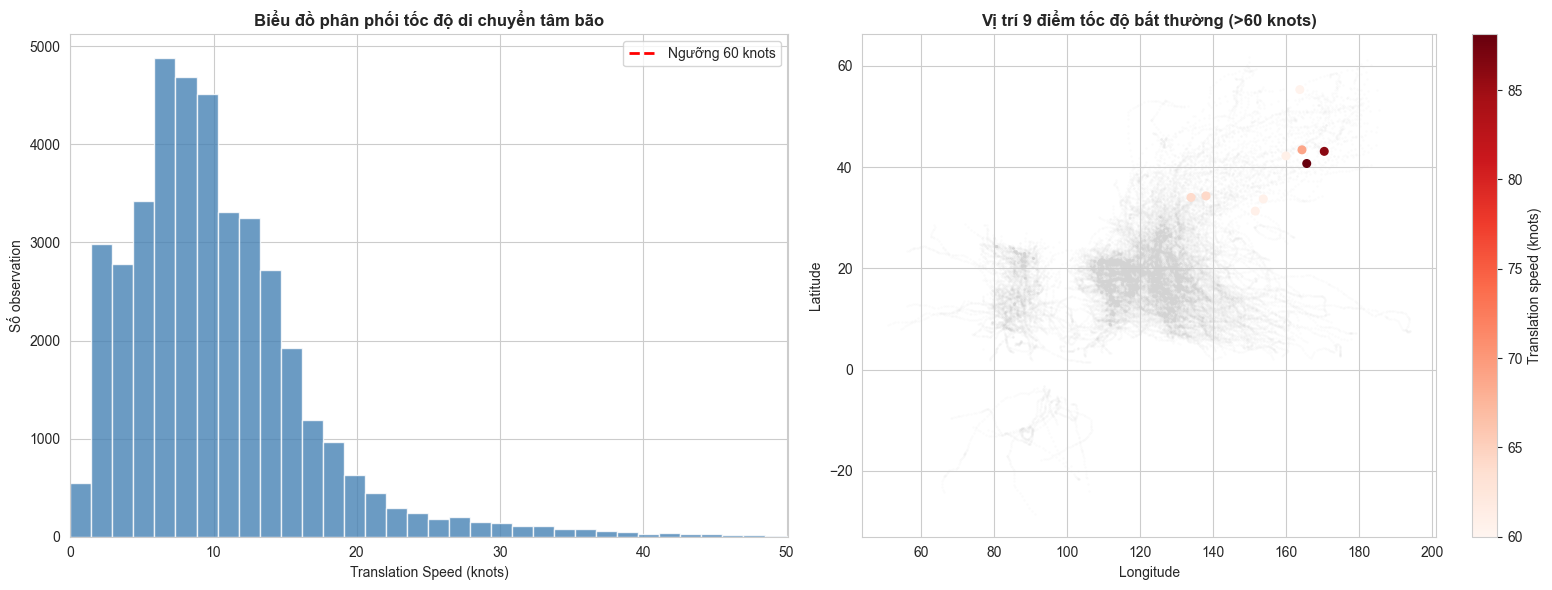

In [11]:
# VẼ BIỂU ĐỒ SAU KHI TÍNH TỐC ĐỘ DI CHUYỂN CỦA BÃO

# Lấy các dữ liệu speed hợp lệ
speed_valid = df['trans_speed_knot'].dropna()
# Tạo khung vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vẽ biểu đồ phân phối tốc độ di chuyển
axes[0].hist(speed_valid, bins=60,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlim(0, speed_valid.quantile(0.999))
# Ngưỡng bất thường thì vẽ đường đỏ dọc, mọi điểm bên phải đường đỏ thì đều bất thường
axes[0].axvline(SPEED_THRESHOLD_KNOT, color='red', linestyle='--', lw=2,
                label=f'Ngưỡng {SPEED_THRESHOLD_KNOT} knots')
# Vẽ các trục ngang và dọc
axes[0].set_xlabel('Translation Speed (knots)')
axes[0].set_ylabel('Số observation')
axes[0].set_title('Biểu đồ phân phối tốc độ di chuyển tâm bão', fontweight='bold')
axes[0].legend()

# Vẽ biểu đồ thể hiện vị trí các điểm bất thường
# Nếu tồn tại điểm bất thường thì vẽ
if n_speed > 0:
    axes[1].scatter(df['LON'], df['LAT'], alpha=0.03, s=1, color='lightgray')
    # Lấy các điểm flag
    flagged = df[df['flag_speed']]
    # Vẽ các điểm bất thường
    sc = axes[1].scatter(flagged['LON'], flagged['LAT'],
                         c=flagged['trans_speed_knot'], cmap='Reds',
                         s=30, zorder=5, vmin=60, vmax=speed_valid.max())
    plt.colorbar(sc, ax=axes[1], label='Translation speed (knots)')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].set_title(f'Vị trí {n_speed} điểm tốc độ bất thường (>60 knots)', fontweight='bold')
# Nếu không có điểm bất thường
else:
    axes[1].text(0.5, 0.5, 'Không có điểm bất thường', ha='center', va='center',
                 fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('Vị trí điểm tốc độ bất thường', fontweight='bold')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

**NHẬN XÉT BIỂU ĐỒ**

1. **Biểu đồ phân phối tốc độ di chuyển tâm bão**
Phân phối lệch phải mạnh, tập trung chủ yếu trong khoảng 0–20 knots — phù hợp thực tế vì hầu hết bão di chuyển chậm. Rất ít điểm bất thường vượt ngưỡng 60 knots.

2. **Biểu đồ vị trí điểm bất thường**
   - Phát hiện 9 điểm bất thường (>60 knots), tốc độ khoảng 60 – 90 knots
   - Có vài điểm nằm ở vĩ độ ~35–45°N, kinh độ ~160–170°E — vùng Tây Bắc Thái Bình Dương, xa Việt Nam
   - Có một vài điểm nhạt màu (cam nhạt ~60–65 knots) rải rác ở vùng  lon 130–140°E, lat 30–35°N, — gần hơn với Việt Nam, cần kiểm tra kỹ hơn
   - Vị trí cách xa cụm dữ liệu chính (10°N–30°N) -> khả năng cao là lỗi tọa độ LAT/LON.

**SOLUTION: Drop 9 điểm bất thường này**

In [12]:
# Drop toàn bộ 9 điểm bất thường này vì không thể biết được chính xác nó là bao nhiêu

n_before     = len(df)
n_speed_drop = int(df['flag_speed'].fillna(False).sum())

if n_speed_drop > 0:
    df = df[~df['flag_speed'].fillna(False)].reset_index(drop=True)
    print(f'Translation speed > {SPEED_THRESHOLD_KNOT}kt: drop {n_speed_drop} observation')
else:
    print(f'Không có điểm translation speed > {SPEED_THRESHOLD_KNOT}kt → không cần xử lý')
    n_speed_drop = 0

print(f'Trước: {n_before:,} dòng -> Sau: {len(df):,} dòng')
print(f'Số storm còn lại: {df["SID"].nunique():,}')

Translation speed > 60kt: drop 9 observation
Trước: 40,847 dòng -> Sau: 40,838 dòng
Số storm còn lại: 719


---
## 3. TỔNG KẾT

## Xử lý Outlier — Handle & Remove

| Loại | Bản chất | Solution |
|---|---|---|
| RI/RW thực sự | **Intrinsic** — hiện tượng vật lý | Giữ nguyên |
| W-P vi phạm nhẹ | **Intrinsic** — noise transition period | Giữ nguyên |
| Spike cô lập | **Extrinsic** | **Cap** về trung bình 2 điểm kề |
| W-P vi phạm nặng | **Extrinsic** | **Cap** WMO_WIND |
| Translation speed > 60kt | **Extrinsic** — tọa độ ghi sai | **Drop** observation |

In [13]:
# TỶ LỆ OUTLIER TRONG DATASET
n_total = n_before  # tổng dòng trước khi xử lý

n_extrinsic = n_speed_drop + n_spike_before + n_heavy_before
n_intrinsic = n_ri + n_rw + (n_incon - n_heavy)

print('TỶ LỆ OUTLIER TRONG DATASET')
print(f'Tổng số dòng ban đầu     : {n_total:,}')
print(f'Intrinsic outlier        : {n_intrinsic:,} obs ({n_intrinsic/n_total*100:.3f}%)')
print(f'Extrinsic outlier        : {n_extrinsic:,} obs ({n_extrinsic/n_total*100:.3f}%)')
print(f'Tổng outlier phát hiện   : {n_intrinsic+n_extrinsic:,} obs ({(n_intrinsic+n_extrinsic)/n_total*100:.3f}%)')
print(f'Dữ liệu sạch (đã xử lý)  : {len(df):,} obs ({len(df)/n_total*100:.3f}%)')

TỶ LỆ OUTLIER TRONG DATASET
Tổng số dòng ban đầu     : 40,847
Intrinsic outlier        : 719 obs (1.760%)
Extrinsic outlier        : 9 obs (0.022%)
Tổng outlier phát hiện   : 728 obs (1.782%)
Dữ liệu sạch (đã xử lý)  : 40,838 obs (99.978%)


## NHẬN XÉT VỀ OUTLIER TRƯỚC VÀ SAU KHI LỌC VÀ XỬ LÝ MISSING

- Extrinsic giảm mạnh từ 123 -> 9 obs sau xử lý — do các điểm tọa độ bất thường (translation speed > 60kt) phần lớn bị loại trong bước lọc và làm sạch dữ liệu.

- Intrinsic tăng về tỷ lệ (0.393% → 1.760%) dù số lượng outlier giảm (893 -> 719) - do dataset sau khi lọc giai đoạn 2000–2025 và xử lý missing nhỏ hơn đáng kể, khiến tỷ lệ Intrinsic trên tổng obs tăng lên.

- Tổng outlier chỉ chiếm ~1.782% dataset sau xử lý — rất thấp, cho thấy bộ dữ liệu có chất lượng tốt.

In [14]:
print('TỔNG KẾT XỬ LÝ OUTLIER')

print(f'[1] RI/RW thực sự           : {n_ri+n_rw:,} obs → INTRINSIC → GIỮ NGUYÊN')
print(f'[2] W-P vi phạm nhẹ         : {n_incon - n_heavy:,} obs → INTRINSIC → GIỮ NGUYÊN')
print(f'[3] Spike cô lập            : {n_spike_before} obs → EXTRINSIC → CAP')
print(f'[4] W-P vi phạm nặng        : {n_heavy_before} obs → EXTRINSIC → CAP')
print(f'[5] Translation speed >60kt : {n_speed_drop} obs → EXTRINSIC → DROP')

print()
print('XỬ LÝ CÁC EXTRINSIC:')
print(f'Dòng bị drop   : {n_speed_drop}')
print(f'Dòng bị cap    : {n_spike_before + n_heavy_before}')
print(f'Dataset cuối   : {len(df):,} dòng | {df["SID"].nunique():,} storms')
print()

TỔNG KẾT XỬ LÝ OUTLIER
[1] RI/RW thực sự           : 715 obs → INTRINSIC → GIỮ NGUYÊN
[2] W-P vi phạm nhẹ         : 4 obs → INTRINSIC → GIỮ NGUYÊN
[3] Spike cô lập            : 0 obs → EXTRINSIC → CAP
[4] W-P vi phạm nặng        : 0 obs → EXTRINSIC → CAP
[5] Translation speed >60kt : 9 obs → EXTRINSIC → DROP

XỬ LÝ CÁC EXTRINSIC:
Dòng bị drop   : 9
Dòng bị cap    : 0
Dataset cuối   : 40,838 dòng | 719 storms



In [15]:
# Xóa các cột tạm thêm vô để xét outlier cho gọn
cols_drop_temp = [
    'LAT_prev', 'LON_prev', 'dt_h', 'dWIND_3h_next', 'dt_8step',
    'flag_wind_extreme', 'flag_pres_extreme',
    'flag_RI', 'flag_RW', 'flag_spike_wind', 'is_isolated_spike',
    'flag_speed', 'wp_inconsistent', 'wp_heavy_violation',
    'dWIND_3h', 'dPRES_3h', 'dWIND_24h',
    'dist_km', 'trans_speed_kmh', 'trans_speed_knot',
]
df = df.drop(columns=[c for c in cols_drop_temp if c in df.columns])


# Lưu file
df.to_csv('data/processed/03_outlier_cleaned.csv', index=False)